In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import joblib

In [2]:
model_df = pd.read_csv("/Users/jasleenkaur/Event-Driven-Congestion/data/processed/model_dataset.csv")

In [3]:
model_df["start_datetime"] = pd.to_datetime(model_df["start_datetime"], utc=True)
model_df = model_df.sort_values("start_datetime").reset_index(drop=True)

In [4]:
print(model_df.shape)

(8057, 44)


In [5]:
model_df.head()

,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,...,month,is_weekend,priority_score,cause_score,closure_score,time_score,weekend_score,eci,congestion_risk_level,high_congestion_risk
0,FKID005760,unplanned,12.966897,77.610555,0.0,0.0,"Richmond Road, Monsignor Dsouza Circle, Ashok ...",NaN,others,False,...,11.0,0,1.0,1.0,0,2,0,4.0,Low,0
1,FKID005762,unplanned,12.981965,77.594477,0.0,0.0,"Cubbon Road, Police Thimmaiah Circle, Gandhi N...",NaN,accident,False,...,11.0,0,3.0,4.0,0,2,0,9.0,Medium,0
2,FKID005761,unplanned,12.962345,77.594553,0.0,0.0,"Mission Road, Ashirwadam Junction, Shanti Naga...",NaN,vehicle_breakdown,False,...,11.0,0,1.0,2.0,0,2,0,5.0,Low,0
3,FKID005197,unplanned,12.921773,77.585775,0.0,0.0,"38th Cross Road, Block 4T East, Jayanagar, Ben...",NaN,water_logging,False,...,11.0,0,1.0,4.0,0,2,0,7.0,Medium,0
4,FKID005763,unplanned,12.927449,77.621406,0.0,0.0,"1st Cross Road, Koramangala Water Tank Junctio...",NaN,pot_holes,False,...,11.0,0,3.0,2.0,0,0,0,5.0,Low,0


In [6]:
print(model_df["high_congestion_risk"].value_counts())

print(
    round(
        model_df["high_congestion_risk"]
        .value_counts(normalize=True) * 100,
        2
    )
)

high_congestion_risk
0    7808
1     249
Name: count, dtype: int64
high_congestion_risk
0    96.91
1     3.09
Name: proportion, dtype: float64


In [7]:
features = [
    "event_type",
    "event_cause",
    "priority",
    "requires_road_closure",   
    "hour",
    "month",
    "is_weekend",
    "corridor",
    "zone"
]

target = "high_congestion_risk"

model_df["requires_road_closure"] = model_df["requires_road_closure"].astype(int)

In [8]:
X = model_df[features]
y = model_df[target]

In [9]:
print(X.shape)
print(y.shape)

(8057, 9)
(8057,)


In [10]:
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [11]:
print(X_train.shape)
print(X_test.shape)

(6445, 9)
(1612, 9)


In [12]:
categorical_features = [
    "event_type",
    "event_cause",
    "priority",
    "corridor",
    "zone"
]

numeric_features = [
    "requires_road_closure",
    "hour",
    "month",
    "is_weekend"
]

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [14]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

In [15]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf)
])

In [16]:
pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
y_pred = pipeline.predict(X_test)

In [18]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

Accuracy: 0.9863523573200993


In [19]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1552
           1       0.74      0.97      0.84        60

    accuracy                           0.99      1612
   macro avg       0.87      0.98      0.92      1612
weighted avg       0.99      0.99      0.99      1612



In [20]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1532   20]
 [   2   58]]


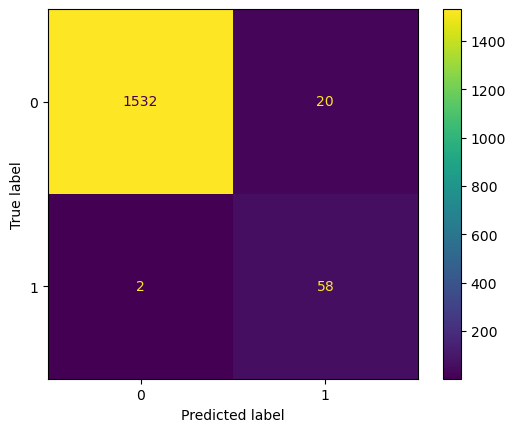

In [21]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [22]:
feature_names = (
    pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

In [23]:
importances = (
    pipeline.named_steps["model"]
    .feature_importances_
)

In [24]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

In [25]:
importance_df.head(20)

,Feature,Importance
54,remainder__requires_road_closure,0.354590
15,cat__event_cause_vehicle_breakdown,0.110712
55,remainder__hour,0.088013
4,cat__event_cause_construction,0.055181
57,remainder__is_weekend,0.044412
0,cat__event_type_planned,0.031331
1,cat__event_type_unplanned,0.031050
17,cat__event_cause_water_logging,0.030072
18,cat__priority_High,0.029141
31,cat__corridor_Non-corridor,0.026961


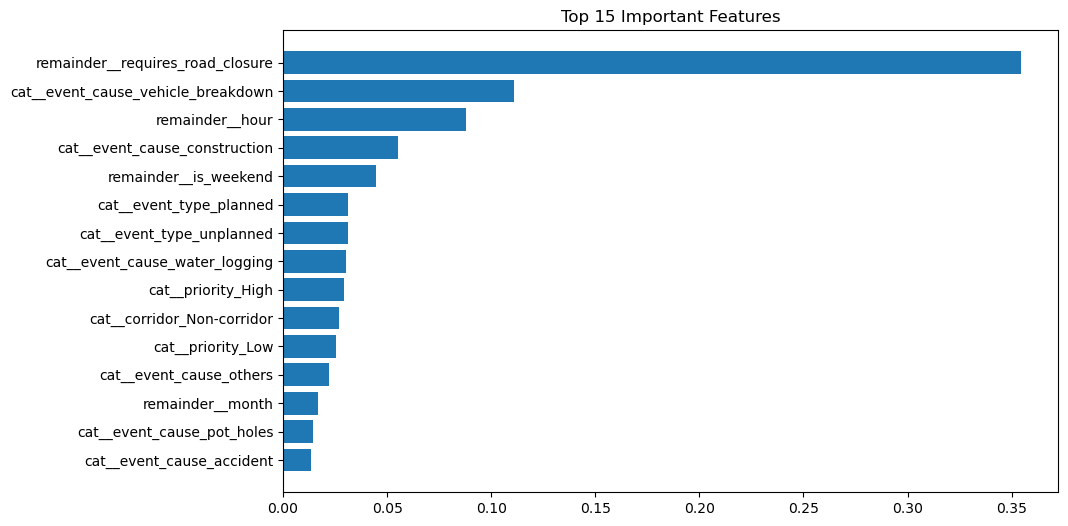

In [26]:
top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

In [27]:
joblib.dump(
    pipeline,
    "../models/high_congestion_risk_model.pkl"
)

['../models/high_congestion_risk_model.pkl']

In [28]:
loaded_model = joblib.load(
    "../models/high_congestion_risk_model.pkl"
)

print("Model loaded successfully")

Model loaded successfully


In [29]:
model_df["requires_road_closure"].value_counts()

requires_road_closure
0    7461
1     596
Name: count, dtype: int64

In [30]:
model_df["end_datetime"].notna().sum()

np.int64(386)